##### Project 2 — Residual & Error Analysis

##### Objective

Diagnose where and why the selected baseline regression model fails.

This notebook does NOT perform new model selection or use the frozen test set.

We will analyze:

1. Overall residual behavior
2. Underprediction vs overprediction
3. Error across delay regimes
4. Error by Product
5. Error by Company
6. Error by State
7. Error across time
8. Relationship between actual delay and prediction error
9. Extreme-delay cases
10. Whether errors indicate a one-stage regression limitation
11. Evidence for the next modeling strategy

##### Prediction Boundary

Prediction is made when the complaint is received.

- Target:- triage_delay_days = Date sent to company - Date received

##### Frozen Data Boundary

- Training and validation data may be used. The final test set must NOT be used for diagnosis, tuning, or model selection.

In [5]:
## Imports & Paths Configurations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import OneHotEncoder

## Paths
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "Data" / "processed"

TRAIN_PATH = DATA_DIR / "project2_train.csv"
VAL_PATH = DATA_DIR / "project2_validation.csv"

TARGET = "triage_delay_days"

RANDOM_STATE = 42

In [6]:
## Load Train & Validation
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

Train shape: (57362, 17)
Validation shape: (12292, 17)

Train columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID', 'triage_delay_days']


In [7]:
## Basic Validation
assert TARGET in train_df.columns
assert TARGET in val_df.columns

assert train_df[TARGET].notna().all()
assert val_df[TARGET].notna().all()

assert np.isfinite(train_df[TARGET]).all()
assert np.isfinite(val_df[TARGET]).all()

print("Target validation passed.")

Target validation passed.


In [8]:
## Feature Engineering Function
def add_project2_features(df):
    df = df.copy()

    date_received = pd.to_datetime(
        df["Date received"],
        errors="coerce",
        utc=True
    )

    narrative = df["Consumer complaint narrative"].fillna("").astype(str)

    df["received_hour"] = date_received.dt.hour
    df["received_dayofweek"] = date_received.dt.dayofweek
    df["received_month"] = date_received.dt.month
    df["received_day"] = date_received.dt.day
    df["is_weekend"] = (
        date_received.dt.dayofweek >= 5
    ).astype(int)

    df["narrative_char_count"] = narrative.str.len()
    df["narrative_word_count"] = (
        narrative.str.split().str.len()
    )
    df["narrative_exclamation_count"] = narrative.str.count("!")
    df["narrative_question_count"] = narrative.str.count(r"\?")

    return df

In [9]:
## Apply Feature Eng
train_fe = add_project2_features(train_df)
val_fe = add_project2_features(val_df)

print("Feature engineering completed.")

Feature engineering completed.


##### selected candidate Feature Groups:
- Metadata + Time + Text + Ridge, using log1p(target).

In [10]:
categorical_features = [
    "Product",
    "Company",
    "State"
]

numeric_features = [
    "received_hour",
    "received_dayofweek",
    "received_month",
    "received_day",
    "is_weekend",
    "narrative_char_count",
    "narrative_word_count",
    "narrative_exclamation_count",
    "narrative_question_count"
]

text_feature = "Consumer complaint narrative"

X_train = train_fe[
    categorical_features + numeric_features + [text_feature]
]

X_val = val_fe[
    categorical_features + numeric_features + [text_feature]
]

y_train = train_fe[TARGET].values
y_val = val_fe[TARGET].values

In [11]:
## Build Pre-preocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=10000,
                sublinear_tf=True
            ),
            text_feature
        )
    ]
)

In [12]:
## Transform Data
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

print("Train transformed shape:", X_train_transformed.shape)
print("Validation transformed shape:", X_val_transformed.shape)

Train transformed shape: (57362, 11852)
Validation transformed shape: (12292, 11852)


In [13]:
## Train Selected Model
ridge_model = Ridge(alpha=1.0)

y_train_log = np.log1p(y_train)

ridge_model.fit(
    X_train_transformed,
    y_train_log
)

print("Log1p Ridge model trained.")

Log1p Ridge model trained.


In [14]:
## Generate Validation Predictions
val_pred_log = ridge_model.predict(X_val_transformed)

val_pred = np.expm1(val_pred_log)

# Delay cannot logically be negative
val_pred = np.maximum(val_pred, 0)

print("Prediction generated.")
print("Prediction min:", val_pred.min())
print("Prediction max:", val_pred.max())

Prediction generated.
Prediction min: 0.0
Prediction max: 56.79964116505115


In [15]:
## Overall Validation Metrics
overall_metrics = {
    "MAE": mean_absolute_error(y_val, val_pred),
    "Median_AE": median_absolute_error(y_val, val_pred),
    "RMSE": np.sqrt(mean_squared_error(y_val, val_pred)),
    "R2": r2_score(y_val, val_pred)
}

pd.DataFrame(
    [overall_metrics]
)

,MAE,Median_AE,RMSE,R2
0,1.373852,0.212139,5.364362,0.011412


In [16]:
## Residual Dataframe
error_df = val_fe.copy()

error_df["actual_delay"] = y_val
error_df["predicted_delay"] = val_pred

error_df["residual"] = (
    error_df["actual_delay"]
    - error_df["predicted_delay"]
)

error_df["absolute_error"] = (
    error_df["residual"].abs()
)

error_df["squared_error"] = (
    error_df["residual"] ** 2
)

error_df["prediction_ratio"] = (
    error_df["predicted_delay"]
    / error_df["actual_delay"].clip(lower=1e-6)
)

print(
    error_df[
        [
            "actual_delay",
            "predicted_delay",
            "residual",
            "absolute_error"
        ]
    ].head()
)

   actual_delay  predicted_delay  residual  absolute_error
0      0.044167         0.050292 -0.006125        0.006125
1      0.023519         0.322813 -0.299294        0.299294
2      0.009433         0.088851 -0.079419        0.079419
3      0.001968         0.000000  0.001968        0.001968
4      0.022315         0.000000  0.022315        0.022315


##### Residual Definition/Interpretation

Residual = Actual - Predicted

Therefore:

Residual > 0
    → model underpredicted

Residual < 0
    → model overpredicted

Residual ≈ 0
    → prediction was close

Absolute Error = |Actual - Predicted|

This distinction matters operationally.

- Underprediction of a long delay can cause an organization
to underestimate workload or fail to intervene early.

- Overprediction can create unnecessary concern or intervention.

In [17]:
## Under Prediction vs Over Prediction
underpredicted = (error_df["residual"] > 0).sum()
overpredicted = (error_df["residual"] < 0).sum()
approximately_correct = (error_df["residual"] == 0).sum()

direction_summary = pd.DataFrame({
    "category": [
        "Underpredicted",
        "Overpredicted",
        "Exactly predicted"
    ],
    "count": [
        underpredicted,
        overpredicted,
        approximately_correct
    ]
})

direction_summary["percentage"] = (
    direction_summary["count"]
    / len(error_df)
    * 100
)

direction_summary

,category,count,percentage
0,Underpredicted,4008,32.606573
1,Overpredicted,8284,67.393427
2,Exactly predicted,0,0.000000


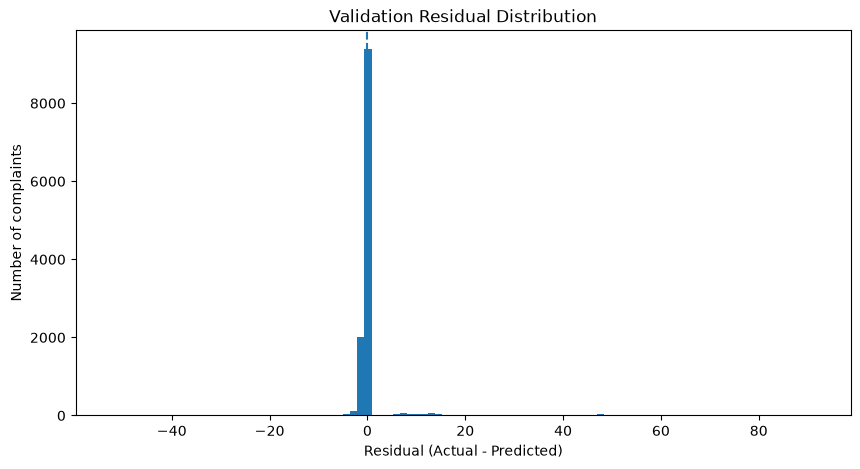

In [18]:
## Residual Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    error_df["residual"],
    bins=100
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Number of complaints")
plt.title("Validation Residual Distribution")

plt.show()

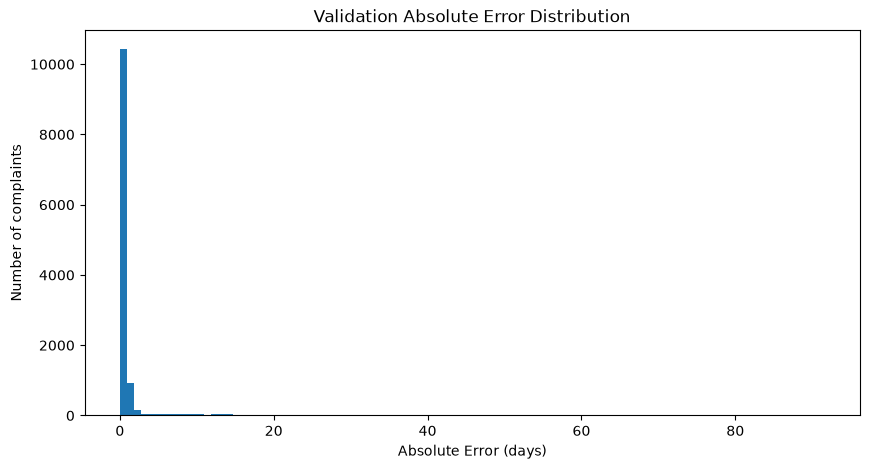

In [19]:
## Absolute Error Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    error_df["absolute_error"],
    bins=100
)

plt.xlabel("Absolute Error (days)")
plt.ylabel("Number of complaints")
plt.title("Validation Absolute Error Distribution")

plt.show()

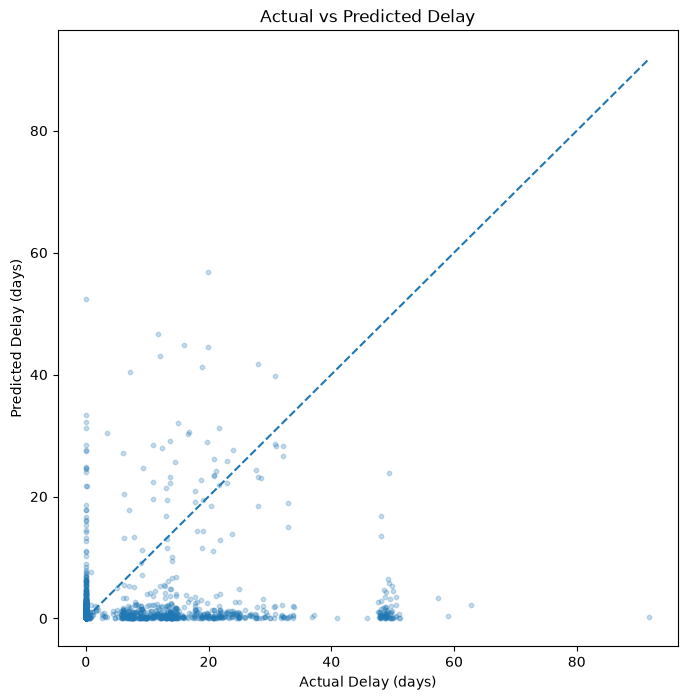

In [20]:
## Actual vs Predicted
plt.figure(figsize=(8, 8))

plt.scatter(
    error_df["actual_delay"],
    error_df["predicted_delay"],
    alpha=0.25,
    s=10
)

max_value = max(
    error_df["actual_delay"].max(),
    error_df["predicted_delay"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delay (days)")
plt.ylabel("Predicted Delay (days)")
plt.title("Actual vs Predicted Delay")

plt.show()

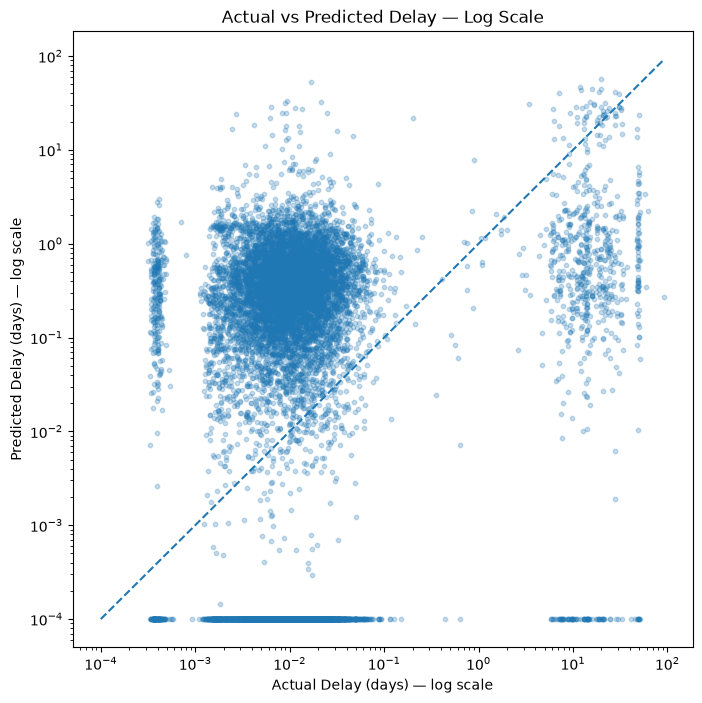

In [21]:
## Actual vs Predicted on Log Scale
plt.figure(figsize=(8, 8))

plt.scatter(
    error_df["actual_delay"] + 1e-4,
    error_df["predicted_delay"] + 1e-4,
    alpha=0.25,
    s=10
)

max_value = max(
    error_df["actual_delay"].max(),
    error_df["predicted_delay"].max()
)

plt.plot(
    [1e-4, max_value + 1],
    [1e-4, max_value + 1],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Delay (days) — log scale")
plt.ylabel("Predicted Delay (days) — log scale")
plt.title("Actual vs Predicted Delay — Log Scale")

plt.show()

In [22]:
## Error By Actual Delay Regime
def delay_regime(days):
    if days <= 0.01:
        return "≤0.01d"
    elif days <= 0.05:
        return "0.01–0.05d"
    elif days <= 1:
        return "0.05–1d"
    elif days <= 7:
        return "1–7d"
    elif days <= 30:
        return "7–30d"
    else:
        return ">30d"


error_df["delay_regime"] = (
    error_df["actual_delay"]
    .apply(delay_regime)
)

In [23]:
## Regime Error Summary
regime_order = [
    "≤0.01d",
    "0.01–0.05d",
    "0.05–1d",
    "1–7d",
    "7–30d",
    ">30d"
]

regime_summary = (
    error_df
    .groupby("delay_regime", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        Median_AE=("absolute_error", "median"),
        RMSE=(
            "squared_error",
            lambda x: np.sqrt(x.mean())
        ),
        mean_residual=("residual", "mean")
    )
    .reindex(regime_order)
)

regime_summary

,count,actual_mean,predicted_mean,MAE,Median_AE,RMSE,mean_residual
delay_regime,,,,,,,
≤0.01d,6182,0.005101,0.393419,0.391110,0.165242,1.243329,-0.388317
0.01–0.05d,5151,0.019540,0.430166,0.421295,0.200441,1.365753,-0.410627
0.05–1d,247,0.107126,0.493922,0.457453,0.226602,1.545592,-0.386796
1–7d,77,5.261156,2.051903,5.025978,5.125588,6.366768,3.209254
7–30d,525,15.232910,3.317901,13.693692,12.792086,15.150262,11.915010
>30d,110,44.891838,3.143601,41.911633,47.145179,43.728484,41.748238


In [24]:
## Regime Error Percentages
regime_summary["percentage"] = (
    regime_summary["count"]
    / len(error_df)
    * 100
)

regime_summary[
    [
        "count",
        "percentage",
        "MAE",
        "Median_AE",
        "RMSE",
        "mean_residual"
    ]
]

,count,percentage,MAE,Median_AE,RMSE,mean_residual
delay_regime,,,,,,
≤0.01d,6182,50.292873,0.391110,0.165242,1.243329,-0.388317
0.01–0.05d,5151,41.905304,0.421295,0.200441,1.365753,-0.410627
0.05–1d,247,2.009437,0.457453,0.226602,1.545592,-0.386796
1–7d,77,0.626424,5.025978,5.125588,6.366768,3.209254
7–30d,525,4.271071,13.693692,12.792086,15.150262,11.915010
>30d,110,0.894891,41.911633,47.145179,43.728484,41.748238


In [25]:
## Tail-Specific Error Analysis
thresholds = [1, 3, 7, 14, 30]

tail_results = []

for threshold in thresholds:
    subset = error_df[
        error_df["actual_delay"] > threshold
    ]

    if len(subset) == 0:
        continue

    tail_results.append({
        "actual_delay_threshold": f">{threshold} days",
        "count": len(subset),
        "percentage": len(subset) / len(error_df) * 100,
        "MAE": mean_absolute_error(
            subset["actual_delay"],
            subset["predicted_delay"]
        ),
        "Median_AE": median_absolute_error(
            subset["actual_delay"],
            subset["predicted_delay"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                subset["actual_delay"],
                subset["predicted_delay"]
            )
        ),
        "mean_residual": subset["residual"].mean()
    })

tail_summary = pd.DataFrame(tail_results)

tail_summary

,actual_delay_threshold,count,percentage,MAE,Median_AE,RMSE,mean_residual
0,>1 days,712,5.792385,17.115826,13.068953,21.657594,15.582582
1,>3 days,699,5.686625,17.417030,13.186856,21.857354,15.857269
2,>7 days,635,5.165962,18.581839,13.803483,22.825711,17.082970
3,>14 days,356,2.896193,25.265344,21.412688,28.971768,23.926051
4,>30 days,110,0.894891,41.911633,47.145179,43.728484,41.748238


In [26]:
## Under Prediction Rate in Tail
tail_direction = []

for threshold in thresholds:
    subset = error_df[
        error_df["actual_delay"] > threshold
    ]

    if len(subset) == 0:
        continue

    tail_direction.append({
        "threshold": f">{threshold}d",
        "count": len(subset),
        "underprediction_rate_%": (
            (subset["residual"] > 0).mean() * 100
        ),
        "overprediction_rate_%": (
            (subset["residual"] < 0).mean() * 100
        ),
        "mean_actual": subset["actual_delay"].mean(),
        "mean_predicted": subset["predicted_delay"].mean()
    })

pd.DataFrame(tail_direction)

,threshold,count,underprediction_rate_%,overprediction_rate_%,mean_actual,mean_predicted
0,>1d,712,93.258427,6.741573,18.736642,3.154060
1,>3d,699,93.562232,6.437768,19.050178,3.192909
2,>7d,635,93.543307,6.456693,20.370677,3.287707
3,>14d,356,93.539326,6.460674,27.855674,3.929623
4,>30d,110,99.090909,0.909091,44.891838,3.143601


In [27]:
## Top Worst Underpredictions
worst_underpredictions = (
    error_df
    .sort_values("residual", ascending=False)
    [
        [
            "Date received",
            "Product",
            "Company",
            "State",
            "actual_delay",
            "predicted_delay",
            "residual",
            "absolute_error",
            "Consumer complaint narrative"
        ]
    ]
    .head(20)
)

worst_underpredictions

,Date received,Product,Company,State,actual_delay,predicted_delay,residual,absolute_error,Consumer complaint narrative
310,2026-05-27 21:56:42+00:00,Debt collection,"Credit Control, LLC",TX,91.845995,0.267602,91.578393,91.578393,"To Whom It XXXX Concern, I am writing regardin..."
380,2026-05-27 22:55:34+00:00,Debt or credit management,A CREDIT SOLUTIONS INC.,FL,62.712801,2.242013,60.470788,60.470788,Complaint Against A Credit Solutions PR / A Cr...
4911,2026-06-06 14:56:25+00:00,Credit card,SYNCHRONY FINANCIAL,VA,59.096435,0.342300,58.754136,58.754136,Synchrony Bank improperly closed my Lowe 's cr...
4490,2026-06-03 12:17:46+00:00,Debt collection,"MRS BPO, LLC",NY,57.345058,3.386184,53.958874,53.958874,I am writing to formally dispute the validity ...
2321,2026-05-30 13:30:20+00:00,Prepaid card,U.S. BANCORP,TX,51.170035,0.000000,51.170035,51.170035,I found a XXXX XXXX debit card that I received...
2341,2026-05-30 21:42:44+00:00,Credit reporting or other personal consumer re...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,50.972234,0.059613,50.912621,50.912621,Trans on is reporting unauthorized inquiries o...
2333,2026-05-30 19:48:38+00:00,Credit card,"CITIBANK, N.A.",CA,51.051019,0.664882,50.386136,50.386136,I am filing a complaint regarding Citibank 's ...
2347,2026-05-31 00:20:13+00:00,Debt collection,"First National Collection Bureau, Inc.",ID,50.489398,0.354808,50.134590,50.134590,"b'Ok, so odd situation.\n\nI got a new phone n..."
2391,2026-05-31 06:41:28+00:00,Debt collection,"CCS Financial Services, Inc.",FL,50.329271,0.196246,50.133025,50.133025,I requested validation and supporting document...
3027,2026-06-01 15:54:40+00:00,Debt collection,"ProCollect, Inc.",VA,50.024884,0.101769,49.923115,49.923115,I originally tried requesting a debt collectio...


In [28]:
## Top Worst Overpredictions
worst_overpredictions = (
    error_df
    .sort_values("residual", ascending=True)
    [
        [
            "Date received",
            "Product",
            "Company",
            "State",
            "actual_delay",
            "predicted_delay",
            "residual",
            "absolute_error",
            "Consumer complaint narrative"
        ]
    ]
    .head(20)
)

worst_overpredictions

,Date received,Product,Company,State,actual_delay,predicted_delay,residual,absolute_error,Consumer complaint narrative
6757,2026-06-09 16:00:58+00:00,Credit card,"Imprint Payments, Inc.",MI,0.016887,52.465349,-52.448462,52.448462,"b'Imprint Payments, Inc.XXXX XXXX XXXX XXXX TX..."
7895,2026-06-10 18:05:36+00:00,Credit card,"Imprint Payments, Inc.",KY,19.905984,56.799641,-36.893657,36.893657,My XXXX XXXX XXXX managed by XXXX XXXX was mi...
2313,2026-05-30 05:21:15+00:00,Credit card,"Imprint Payments, Inc.",WA,11.711701,46.728035,-35.016334,35.016334,"On XX/XX/XXXX, I purchased a sofa from XXXX XX..."
7042,2026-06-09 19:49:54+00:00,"Payday loan, title loan, personal loan, or adv...","POWERPAY, LLC",MD,0.009167,33.345005,-33.335838,33.335838,I am the contractor/merchant for a home improv...
4718,2026-06-03 18:59:50+00:00,Credit card,"Imprint Payments, Inc.",CA,7.143495,40.377279,-33.233783,33.233783,b'I received an Imprint Mastercard credit card...
2226,2026-05-29 19:21:39+00:00,Credit card,"Imprint Payments, Inc.",AZ,0.021435,32.293730,-32.272295,32.272295,"My complaint concerns Imprint Payments , Inc ...."
7878,2026-06-10 17:55:06+00:00,Debt collection,"GF SunStrong Management Holdings, LLC",CA,0.008912,31.296746,-31.287834,31.287834,"In XXXX and XX/XX/year>, I submitted a written..."
2212,2026-05-29 19:09:24+00:00,Credit card,"Imprint Payments, Inc.",MO,12.136516,42.981076,-30.844560,30.844560,XXXX XXXX stopped handling XXXX XXXX took ove...
10250,2026-06-14 21:12:08+00:00,Debt collection,"Tilt Finance, Inc.",NY,15.933819,44.862744,-28.928924,28.928924,"Remove this account from my credit report, til..."
8342,2026-06-11 01:54:09+00:00,"Payday loan, title loan, personal loan, or adv...","GF SunStrong Management Holdings, LLC",AZ,0.006238,28.495256,-28.489017,28.489017,I am a homeowner disputing the validity of an ...


In [29]:
## Error By Product
product_error = (
    error_df
    .groupby("Product", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        Median_AE=("absolute_error", "median"),
        mean_residual=("residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

product_error

,count,actual_mean,predicted_mean,MAE,Median_AE,mean_residual
Product,,,,,,
Debt or credit management,82,2.623965,1.392706,2.534016,0.358314,1.231259
Prepaid card,151,1.556725,0.547147,1.968345,0.352988,1.009578
"Payday loan, title loan, personal loan, or advance loan",454,1.161836,0.987165,1.848560,0.362286,0.174671
Credit card,2083,1.602063,1.040355,1.671273,0.204765,0.561709
Debt collection,3927,1.300883,0.522555,1.645110,0.261418,0.778328
Student loan,405,1.197651,0.528545,1.472177,0.272400,0.669106
Vehicle loan or lease,569,1.154869,0.438859,1.469811,0.269093,0.716010
"Money transfer, virtual currency, or money service",912,0.912713,0.642700,1.377671,0.245545,0.270012
Mortgage,834,0.800151,0.442679,1.123453,0.293891,0.357472


In [30]:
## Product Error with Sufficient Sample Size
product_error_reliable = product_error[
    product_error["count"] >= 100
]

product_error_reliable

,count,actual_mean,predicted_mean,MAE,Median_AE,mean_residual
Product,,,,,,
Prepaid card,151,1.556725,0.547147,1.968345,0.352988,1.009578
"Payday loan, title loan, personal loan, or advance loan",454,1.161836,0.987165,1.848560,0.362286,0.174671
Credit card,2083,1.602063,1.040355,1.671273,0.204765,0.561709
Debt collection,3927,1.300883,0.522555,1.645110,0.261418,0.778328
Student loan,405,1.197651,0.528545,1.472177,0.272400,0.669106
Vehicle loan or lease,569,1.154869,0.438859,1.469811,0.269093,0.716010
"Money transfer, virtual currency, or money service",912,0.912713,0.642700,1.377671,0.245545,0.270012
Mortgage,834,0.800151,0.442679,1.123453,0.293891,0.357472
Checking or savings account,2286,0.579539,0.290106,0.787244,0.112653,0.289433


In [31]:
## Product Underprediction
product_direction = (
    error_df
    .groupby("Product", observed=True)
    .agg(
        count=("actual_delay", "size"),
        underprediction_rate=(
            "residual",
            lambda x: (x > 0).mean()
        ),
        mean_residual=("residual", "mean")
    )
    .sort_values("mean_residual", ascending=False)
)

product_direction["underprediction_rate_%"] = (
    product_direction["underprediction_rate"] * 100
)

product_direction

,count,underprediction_rate,mean_residual,underprediction_rate_%
Product,,,,
Debt or credit management,82,0.341463,1.231259,34.146341
Prepaid card,151,0.211921,1.009578,21.192053
Debt collection,3927,0.279857,0.778328,27.985740
Vehicle loan or lease,569,0.282953,0.716010,28.295255
Student loan,405,0.323457,0.669106,32.345679
Credit card,2083,0.344695,0.561709,34.469515
Mortgage,834,0.290168,0.357472,29.016787
Checking or savings account,2286,0.394576,0.289433,39.457568
"Money transfer, virtual currency, or money service",912,0.303728,0.270012,30.372807


In [32]:
## Error BY Company
company_error = (
    error_df
    .groupby("Company", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        Median_AE=("absolute_error", "median"),
        mean_residual=("residual", "mean")
    )
)

In [33]:
## Companies with Sufficient Volume
company_error_reliable = (
    company_error[
        company_error["count"] >= 100
    ]
    .sort_values("MAE", ascending=False)
)

company_error_reliable.head(20)

,count,actual_mean,predicted_mean,MAE,Median_AE,mean_residual
Company,,,,,,
"Bread Financial Holdings, Inc.",118,2.430570,1.128360,3.199974,1.098629,1.302210
SYNCHRONY FINANCIAL,270,1.855269,0.473211,2.171855,0.401836,1.382057
U.S. BANCORP,137,1.668302,0.292421,1.923954,0.195171,1.375881
ENCORE CAPITAL GROUP INC.,239,1.457977,0.344234,1.730484,0.089409,1.113743
"CITIBANK, N.A.",411,1.443465,0.307625,1.679459,0.194700,1.135841
AMERICAN EXPRESS COMPANY,179,0.901159,0.297163,1.155280,0.198722,0.603996
"Block, Inc.",435,0.947319,0.256111,1.136928,0.171414,0.691208
WELLS FARGO & COMPANY,460,0.977798,0.223259,1.134598,0.077575,0.754539
MOHELA,177,0.879189,0.308642,1.103522,0.208743,0.570547


In [34]:
## Companies with Strongest Underpredictions
company_underprediction = (
    company_error[
        company_error["count"] >= 100
    ]
    .sort_values("mean_residual", ascending=False)
)

company_underprediction.head(20)

,count,actual_mean,predicted_mean,MAE,Median_AE,mean_residual
Company,,,,,,
SYNCHRONY FINANCIAL,270,1.855269,0.473211,2.171855,0.401836,1.382057
U.S. BANCORP,137,1.668302,0.292421,1.923954,0.195171,1.375881
"Bread Financial Holdings, Inc.",118,2.430570,1.128360,3.199974,1.098629,1.302210
"CITIBANK, N.A.",411,1.443465,0.307625,1.679459,0.194700,1.135841
ENCORE CAPITAL GROUP INC.,239,1.457977,0.344234,1.730484,0.089409,1.113743
WELLS FARGO & COMPANY,460,0.977798,0.223259,1.134598,0.077575,0.754539
"Block, Inc.",435,0.947319,0.256111,1.136928,0.171414,0.691208
AMERICAN EXPRESS COMPANY,179,0.901159,0.297163,1.155280,0.198722,0.603996
CAPITAL ONE FINANCIAL CORPORATION,532,0.853542,0.272231,1.070774,0.148514,0.581310


In [35]:
## Error By State
state_error = (
    error_df
    .groupby("State", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean")
    )
    .sort_values("MAE", ascending=False)
)

state_error[state_error["count"] >= 100]

,count,actual_mean,predicted_mean,MAE,mean_residual
State,,,,,
AR,102,1.577690,0.321739,1.863796,1.255951
VA,289,1.471064,0.628831,1.703851,0.842232
NV,168,1.386755,0.725638,1.691989,0.661117
SC,222,1.286826,0.598418,1.655970,0.688408
OR,111,1.499085,1.129366,1.645575,0.369719
FL,1283,1.401260,0.572757,1.619515,0.828504
MI,251,1.166516,0.763516,1.584687,0.403000
TN,229,1.228344,0.498357,1.583884,0.729987
CA,1481,1.229721,0.615655,1.551412,0.614066


In [36]:
## Create Received TimeStamp
error_df["received_timestamp"] = pd.to_datetime(
    error_df["Date received"],
    errors="coerce",
    utc=True
)

error_df["received_month_name"] = (
    error_df["received_timestamp"]
    .dt.strftime("%Y-%m")
)

error_df["received_day_name"] = (
    error_df["received_timestamp"]
    .dt.day_name()
)

error_df["received_hour"] = (
    error_df["received_timestamp"]
    .dt.hour
)

In [37]:
## Error By Month
monthly_error = (
    error_df
    .groupby("received_month_name", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        Median_AE=("absolute_error", "median"),
        mean_residual=("residual", "mean")
    )
)

monthly_error

,count,actual_mean,predicted_mean,MAE,Median_AE,mean_residual
received_month_name,,,,,,
2026-05,2701,1.485500,0.626049,1.671810,0.215895,0.859451
2026-06,9591,0.989136,0.555170,1.289942,0.210943,0.433966


In [38]:
## Error By Day Of Week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_error = (
    error_df
    .groupby("received_day_name", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean")
    )
    .reindex(day_order)
)

dow_error

,count,actual_mean,predicted_mean,MAE,mean_residual
received_day_name,,,,,
Monday,2395,0.776310,0.464013,1.069352,0.312297
Tuesday,2609,0.821824,0.527418,1.085145,0.294405
Wednesday,2198,1.220540,0.522512,1.501425,0.698028
Thursday,2130,1.168212,0.609540,1.420818,0.558672
Friday,1524,1.316727,0.558197,1.576503,0.758530
Saturday,366,3.778859,1.438875,3.881036,2.339984
Sunday,1070,0.873776,0.658059,1.257597,0.215718


In [39]:
## Error By Hour
hour_error = (
    error_df
    .groupby("received_hour", observed=True)
    .agg(
        count=("actual_delay", "size"),
        actual_mean=("actual_delay", "mean"),
        predicted_mean=("predicted_delay", "mean"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean")
    )
)

hour_error

,count,actual_mean,predicted_mean,MAE,mean_residual
received_hour,,,,,
0,455,1.027590,0.439570,1.383538,0.588020
1,397,1.307514,0.862945,1.561202,0.444569
2,349,1.515721,0.472122,1.856647,1.043599
3,324,0.397017,0.446209,0.773156,-0.049191
4,287,1.025974,0.361674,1.316867,0.664300
5,224,1.119200,0.719001,1.639188,0.400199
6,174,1.026426,0.482110,1.249606,0.544316
7,177,0.645468,0.263563,0.847636,0.381905
8,145,0.397050,0.360113,0.663908,0.036937


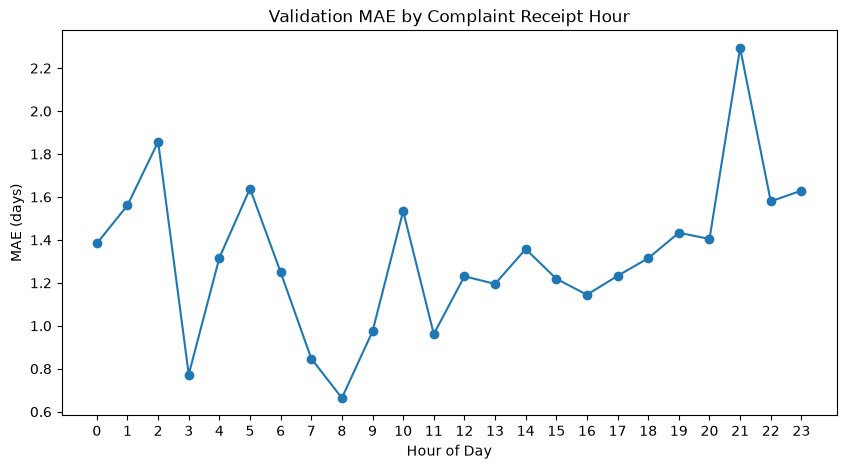

In [40]:
## Plot MAE By Hour
plt.figure(figsize=(10, 5))

plt.plot(
    hour_error.index,
    hour_error["MAE"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("MAE (days)")
plt.title("Validation MAE by Complaint Receipt Hour")
plt.xticks(range(0, 24))

plt.show()

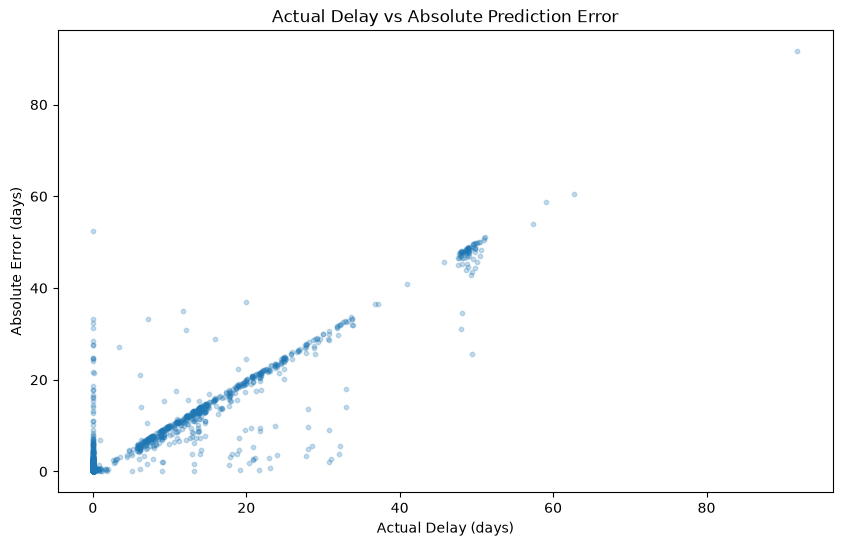

In [41]:
## Actual Delay vs Absolute Error
plt.figure(figsize=(10, 6))

plt.scatter(
    error_df["actual_delay"],
    error_df["absolute_error"],
    alpha=0.25,
    s=10
)

plt.xlabel("Actual Delay (days)")
plt.ylabel("Absolute Error (days)")
plt.title("Actual Delay vs Absolute Prediction Error")

plt.show()

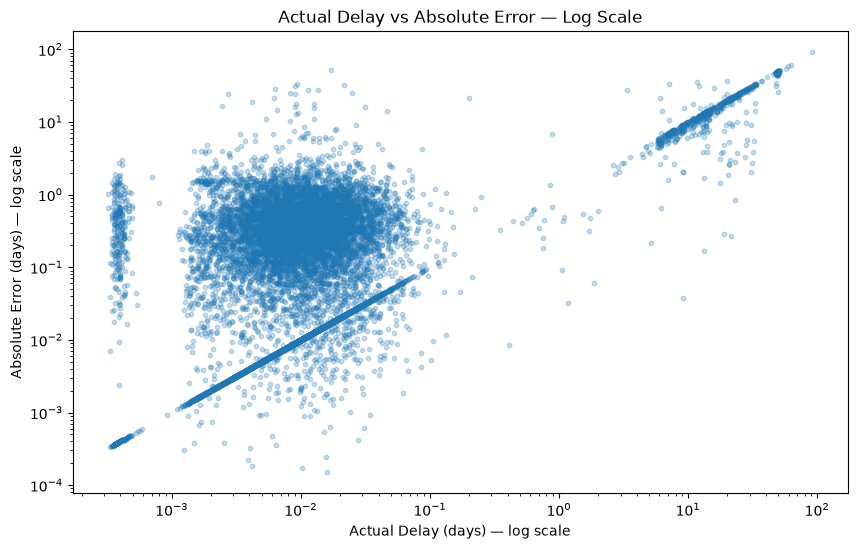

In [42]:
## Log-Scale Error Relationship
plt.figure(figsize=(10, 6))

plt.scatter(
    error_df["actual_delay"] + 1e-4,
    error_df["absolute_error"] + 1e-4,
    alpha=0.25,
    s=10
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Delay (days) — log scale")
plt.ylabel("Absolute Error (days) — log scale")
plt.title("Actual Delay vs Absolute Error — Log Scale")

plt.show()

In [43]:
## Prediction Shrinking Analysis
prediction_by_regime = (
    error_df
    .groupby("delay_regime", observed=True)
    .agg(
        actual_median=("actual_delay", "median"),
        actual_mean=("actual_delay", "mean"),
        predicted_median=("predicted_delay", "median"),
        predicted_mean=("predicted_delay", "mean")
    )
    .reindex(regime_order)
)

prediction_by_regime

,actual_median,actual_mean,predicted_median,predicted_mean
delay_regime,,,,
≤0.01d,0.005093,0.005101,0.170835,0.393419
0.01–0.05d,0.016944,0.019540,0.220375,0.430166
0.05–1d,0.062454,0.107126,0.281464,0.493922
1–7d,6.005197,5.261156,0.730903,2.051903
7–30d,13.904155,15.232910,0.494814,3.317901
>30d,48.512141,44.891838,0.577204,3.143601


###### Calibration-style tail analysis

- Here we ask:- When the model predicts a high delay, does the actual delay really become high?

- Create prediction buckets.

In [44]:
error_df["prediction_bucket"] = pd.cut(
    error_df["predicted_delay"],
    bins=[
        -np.inf,
        0.01,
        0.05,
        1,
        7,
        30,
        np.inf
    ],
    labels=[
        "≤0.01d",
        "0.01–0.05d",
        "0.05–1d",
        "1–7d",
        "7–30d",
        ">30d"
    ]
)

In [45]:
## Predicted Buckets vs Actual Outcome
calibration_summary = (
    error_df
    .groupby("prediction_bucket", observed=True)
    .agg(
        count=("actual_delay", "size"),
        mean_predicted=("predicted_delay", "mean"),
        mean_actual=("actual_delay", "mean"),
        median_actual=("actual_delay", "median"),
        actual_p90=("actual_delay", lambda x: x.quantile(0.90)),
        actual_p95=("actual_delay", lambda x: x.quantile(0.95))
    )
)

calibration_summary

,count,mean_predicted,mean_actual,median_actual,actual_p90,actual_p95
prediction_bucket,,,,,,
≤0.01d,3382,0.000237,0.463853,0.008924,0.028810,0.043079
0.01–0.05d,626,0.029048,0.543087,0.008993,0.031568,0.054841
0.05–1d,7018,0.375434,0.966949,0.010208,0.036377,1.322696
1–7d,1161,1.754867,2.961529,0.011215,11.236875,18.525081
7–30d,87,18.636787,12.964126,12.988843,29.471525,32.711566
>30d,18,39.055912,13.230355,15.507164,23.645480,28.405104


In [46]:
## Log-Delay Detection from Regression Predictions
threshold = 7

actual_delayed = (
    error_df["actual_delay"] > threshold
)

predicted_delayed = (
    error_df["predicted_delay"] > threshold
)

diagnostic_confusion = pd.crosstab(
    actual_delayed,
    predicted_delayed,
    rownames=["Actual > 7d"],
    colnames=["Predicted > 7d"]
)

diagnostic_confusion

Predicted > 7d,False,True
Actual > 7d,,
False,11619,38
True,568,67


In [47]:
## Tail Recall/Precision Diagnostic
tp = (
    actual_delayed &
    predicted_delayed
).sum()

fp = (
    ~actual_delayed &
    predicted_delayed
).sum()

fn = (
    actual_delayed &
    ~predicted_delayed
).sum()

tail_precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else np.nan
)

tail_recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

pd.DataFrame({
    "metric": [
        "Precision for >7d",
        "Recall for >7d"
    ],
    "value": [
        tail_precision,
        tail_recall
    ]
})

,metric,value
0,Precision for >7d,0.638095
1,Recall for >7d,0.105512


In [48]:
## Analyze Extreme Actual Delays
extreme_cases = (
    error_df[
        error_df["actual_delay"] > 30
    ]
    .sort_values(
        "actual_delay",
        ascending=False
    )
)

print(
    "Number of >30 day validation cases:",
    len(extreme_cases)
)

extreme_cases[
    [
        "Date received",
        "Product",
        "Company",
        "State",
        "actual_delay",
        "predicted_delay",
        "residual",
        "absolute_error"
    ]
].head(30)

Number of >30 day validation cases: 110


,Date received,Product,Company,State,actual_delay,predicted_delay,residual,absolute_error
310,2026-05-27 21:56:42+00:00,Debt collection,"Credit Control, LLC",TX,91.845995,0.267602,91.578393,91.578393
380,2026-05-27 22:55:34+00:00,Debt or credit management,A CREDIT SOLUTIONS INC.,FL,62.712801,2.242013,60.470788,60.470788
4911,2026-06-06 14:56:25+00:00,Credit card,SYNCHRONY FINANCIAL,VA,59.096435,0.342300,58.754136,58.754136
4490,2026-06-03 12:17:46+00:00,Debt collection,"MRS BPO, LLC",NY,57.345058,3.386184,53.958874,53.958874
2321,2026-05-30 13:30:20+00:00,Prepaid card,U.S. BANCORP,TX,51.170035,0.000000,51.170035,51.170035
2333,2026-05-30 19:48:38+00:00,Credit card,"CITIBANK, N.A.",CA,51.051019,0.664882,50.386136,50.386136
2341,2026-05-30 21:42:44+00:00,Credit reporting or other personal consumer re...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,50.972234,0.059613,50.912621,50.912621
3396,2026-06-01 20:59:22+00:00,Debt collection,The Receivable Management Services LLC,OH,50.586100,2.202517,48.383583,48.383583
2346,2026-05-31 00:16:45+00:00,Debt collection,"MRS BPO, LLC",MI,50.511308,3.500510,47.010798,47.010798
2347,2026-05-31 00:20:13+00:00,Debt collection,"First National Collection Bureau, Inc.",ID,50.489398,0.354808,50.134590,50.134590


In [49]:
## Extreme Delay Distribution By Product 
extreme_product = (
    extreme_cases
    .groupby("Product", observed=True)
    .size()
    .sort_values(ascending=False)
)

extreme_product

Product
Debt collection                                            49
Credit card                                                22
Checking or savings account                                 9
Money transfer, virtual currency, or money service          6
Vehicle loan or lease                                       5
Mortgage                                                    5
Payday loan, title loan, personal loan, or advance loan     5
Student loan                                                4
Debt or credit management                                   2
Prepaid card                                                2
Credit reporting or other personal consumer reports         1
dtype: int64

In [50]:
## Exteme Delay Distribution By Company
extreme_company = (
    extreme_cases
    .groupby("Company", observed=True)
    .size()
    .sort_values(ascending=False)
)

extreme_company.head(20)

Company
CITIBANK, N.A.                            7
Imprint Payments, Inc.                    6
MRS BPO, LLC                              6
CCS Financial Services, Inc.              5
WELLS FARGO & COMPANY                     5
U.S. BANCORP                              4
SYNCHRONY FINANCIAL                       3
Self Financial Inc.                       3
UNITED SERVICES AUTOMOBILE ASSOCIATION    3
Shellpoint Partners, LLC                  2
Monterey Financial Services LLC           2
I.C. System, Inc.                         2
TClub Inc                                 2
Credit Control, LLC                       2
CAPITAL ONE FINANCIAL CORPORATION         2
Bread Financial Holdings, Inc.            2
Financial Credit Network Inc              2
ENCORE CAPITAL GROUP INC.                 2
AUTO FINANCE USA, LLC                     1
A CREDIT SOLUTIONS INC.                   1
dtype: int64

In [51]:
### Narrative Length vs Error
narrative_error = (
    error_df
    .assign(
        narrative_length_bucket=pd.qcut(
            error_df["narrative_word_count"],
            q=5,
            duplicates="drop"
        )
    )
    .groupby(
        "narrative_length_bucket",
        observed=True
    )
    .agg(
        count=("actual_delay", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual_delay", "mean")
    )
)

narrative_error

,count,MAE,mean_residual,actual_mean
narrative_length_bucket,,,,
"(5.999, 80.0]",2479,1.189107,0.482349,0.936817
"(80.0, 141.0]",2442,1.399831,0.419505,1.105677
"(141.0, 225.0]",2479,1.424084,0.525072,1.131037
"(225.0, 345.0]",2435,1.463239,0.563571,1.177677
"(345.0, 3887.0]",2457,1.395165,0.646895,1.141725


In [52]:
### Error Correlation Table
numeric_error_features = [
    "actual_delay",
    "predicted_delay",
    "residual",
    "absolute_error",
    "narrative_word_count",
    "narrative_char_count",
    "received_hour",
    "received_dayofweek",
    "received_month"
]

error_df[
    numeric_error_features
].corr(numeric_only=True)["absolute_error"].sort_values(
    ascending=False
)

absolute_error          1.000000
actual_delay            0.946846
residual                0.832661
predicted_delay         0.289242
received_dayofweek      0.045082
received_hour           0.016458
narrative_word_count    0.013355
narrative_char_count    0.011133
received_month         -0.030493
Name: absolute_error, dtype: float64

In [53]:
## Check The weather Predictions Are Compressed 
prediction_summary = pd.Series({
    "Actual mean": error_df["actual_delay"].mean(),
    "Actual std": error_df["actual_delay"].std(),
    "Actual p95": error_df["actual_delay"].quantile(0.95),
    "Actual p99": error_df["actual_delay"].quantile(0.99),
    "Predicted mean": error_df["predicted_delay"].mean(),
    "Predicted std": error_df["predicted_delay"].std(),
    "Predicted p95": error_df["predicted_delay"].quantile(0.95),
    "Predicted p99": error_df["predicted_delay"].quantile(0.99),
    "Actual max": error_df["actual_delay"].max(),
    "Predicted max": error_df["predicted_delay"].max()
})

prediction_summary

Actual mean        1.098205
Actual std         5.395453
Actual p95         7.419414
Actual p99        27.991120
Predicted mean     0.570744
Predicted std      2.293690
Predicted p95      1.485197
Predicted p99      5.567931
Actual max        91.845995
Predicted max     56.799641
dtype: float64

##### Save the Diagnostic Results
OUTPUT_DIR = Path("Data/analysis/project2")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

regime_summary.to_csv(
    OUTPUT_DIR / "project2_regime_error_summary.csv"
)

tail_summary.to_csv(
    OUTPUT_DIR / "project2_tail_error_summary.csv",
    index=False
)

product_error.to_csv(
    OUTPUT_DIR / "project2_product_error_summary.csv"
)

company_error.to_csv(
    OUTPUT_DIR / "project2_company_error_summary.csv"
)

state_error.to_csv(
    OUTPUT_DIR / "project2_state_error_summary.csv"
)

monthly_error.to_csv(
    OUTPUT_DIR / "project2_monthly_error_summary.csv"
)

dow_error.to_csv(
    OUTPUT_DIR / "project2_dayofweek_error_summary.csv"
)

calibration_summary.to_csv(
    OUTPUT_DIR / "project2_prediction_calibration_summary.csv"
)

print("Diagnostic summaries saved.")

In [ ]:
## Save the Validation Predictions
prediction_columns = [
    "Complaint ID",
    "Date received",
    "Product",
    "Company",
    "State",
    TARGET
]

available_prediction_columns = [
    col for col in prediction_columns
    if col in error_df.columns
]

prediction_output = error_df[
    available_prediction_columns
].copy()

prediction_output["predicted_delay"] = (
    error_df["predicted_delay"]
)

prediction_output["residual"] = (
    error_df["residual"]
)

prediction_output["absolute_error"] = (
    error_df["absolute_error"]
)

prediction_output.to_csv(
    OUTPUT_DIR / "project2_validation_predictions.csv",
    index=False
)

print("Validation predictions saved.")

In [54]:
## Final Diagnostic Summary
final_summary = pd.DataFrame({
    "metric": [
        "Validation MAE",
        "Validation Median AE",
        "Validation RMSE",
        "Validation R2",
        "Underprediction rate",
        "Overprediction rate",
        "MAE for actual >1d",
        "MAE for actual >7d",
        "MAE for actual >30d",
        "Actual p99 delay",
        "Predicted p99 delay",
        "Actual maximum delay",
        "Predicted maximum delay"
    ],
    "value": [
        mean_absolute_error(y_val, val_pred),
        median_absolute_error(y_val, val_pred),
        np.sqrt(mean_squared_error(y_val, val_pred)),
        r2_score(y_val, val_pred),
        (error_df["residual"] > 0).mean(),
        (error_df["residual"] < 0).mean(),
        error_df.loc[
            error_df["actual_delay"] > 1,
            "absolute_error"
        ].mean(),
        error_df.loc[
            error_df["actual_delay"] > 7,
            "absolute_error"
        ].mean(),
        error_df.loc[
            error_df["actual_delay"] > 30,
            "absolute_error"
        ].mean(),
        error_df["actual_delay"].quantile(0.99),
        error_df["predicted_delay"].quantile(0.99),
        error_df["actual_delay"].max(),
        error_df["predicted_delay"].max()
    ]
})

final_summary

,metric,value
0,Validation MAE,1.373852
1,Validation Median AE,0.212139
2,Validation RMSE,5.364362
3,Validation R2,0.011412
4,Underprediction rate,0.326066
5,Overprediction rate,0.673934
6,MAE for actual >1d,17.115826
7,MAE for actual >7d,18.581839
8,MAE for actual >30d,41.911633
9,Actual p99 delay,27.991120


##### Analysis Insights

##### 1. Overall Model Behavior

The selected Log1p Ridge model achieves approximately:

- MAE: [VALUE] days
- Median Absolute Error: [VALUE] days
- RMSE: [VALUE] days
- R²: [VALUE]

The model does not outperform the Train Median baseline on overall MAE.

Therefore, the current model should not yet be considered a superior operational latency predictor.

---

##### 2. Error Is Not Uniform Across the Target Distribution

Prediction error increases substantially as actual triage delay increases.

The model performs relatively better for the dominant near-immediate regime but struggles increasingly with delayed complaints.

This indicates that overall MAE alone hides important tail behavior.

---

##### 3. Long-Delay Underprediction

For complaints with actual delays above [THRESHOLD]:

- MAE = [VALUE]
- Mean residual = [VALUE]
- Underprediction rate = [VALUE]%

This indicates [whether / whether not] the model systematically underestimates long delays.

---

##### 4. Regression-to-the-Center Behavior

The actual target contains a large near-immediate population and a relatively small long-delay tail.

The model's predicted distribution is substantially narrower than the actual distribution.

Therefore, the model tends to regress extreme delays toward more typical values.

This is a fundamental limitation of the current one-stage regression formulation.

---

##### 5. Product-Level Behavior

Error varies across Products.

The highest-error Products are:

1. [PRODUCT]
2. [PRODUCT]
3. [PRODUCT]

However, group-level differences should not automatically be interpreted as causal effects.

---

##### 6. Company-Level Behavior

Company-level error analysis shows [strong / moderate / weak] heterogeneity.

Some companies exhibit systematic underprediction or overprediction.

This suggests that organizational/process information may contain predictive signal, although robustness against unseen companies must be evaluated separately.

---

##### 7. Temporal Error Behavior

Prediction error varies across [months / weekdays / hours].

This is consistent with the process drift identified during the temporal split analysis.

Therefore, temporal robustness must remain an important part of subsequent model evaluation.

---

##### 8. Key Modeling Diagnosis

The current evidence suggests that the challenge is not simply insufficient feature complexity.

The target itself contains two qualitatively different regimes:

1. Near-immediate processing
2. Rare but operationally significant long delays

A single continuous regression model is attempting to model both regimes simultaneously.

The current model performs reasonably on the dominant regime but fails to adequately identify and estimate the long-delay regime.

---

##### 9. Next Modeling Question

The next phase should therefore investigate whether the problem is better formulated as:

    Stage 1:
    Predict probability of entering a delayed-processing regime

    Stage 2:
    Predict delay duration conditional on entering that regime

This should only be adopted if the diagnostic results demonstrate that the delayed regime contains learnable signal.

---

##### 10. Important Limitation

- The final test set remains untouched.

- All observations and conclusions in this notebook are based only on the training/validation development boundary.

- The final test set will be used only after model selection is frozen.